<a href="https://colab.research.google.com/github/GFrankTI/tps-modelizado/blob/main/Copia_de_Practica_Unidad_2_Algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [34]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

In [35]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

In [36]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [37]:
# 1. Función de Aptitud
def fitness_func(ga_instance, TASAS_OBRA, solution): #solution_idx):
    return np.sum(solution)

# 2. Configurar el Algoritmo
ga_instance = pygad.GA(
    num_generations=50,
    num_parents_mating=MAX_OPERARIOS,
    fitness_func=fitness_func,
    sol_per_pop=NUM_TAREAS,
    num_genes=10,
    init_range_low=0,
    init_range_high=2,
    random_mutation_min_val=0,
    random_mutation_max_val=2,
    mutation_by_replacement=True,
    gene_type=int,
    parent_selection_type="rws", # Ruleta
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10)

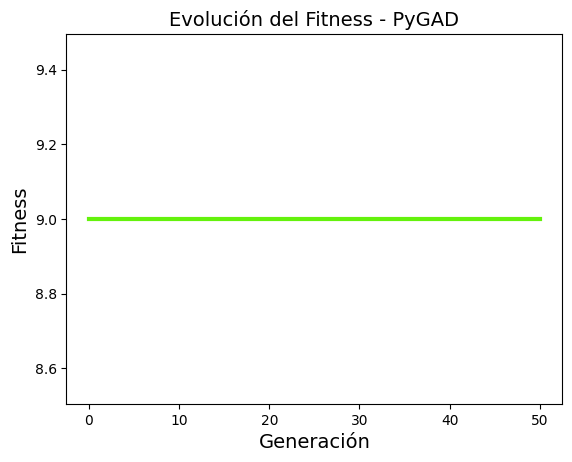

Mejor Solución: [1 0 1 0 1 0 0 0 1 1]
Valor de Aptitud: 9


In [38]:
# 3. Ejecución
ga_instance.run()

# 4. Generación del Gráfico
# PyGAD guarda internamente el historial de fitness
ga_instance.plot_fitness(title="Evolución del Fitness - PyGAD", xlabel="Generación", ylabel="Fitness")
plt.show()

# 5. Resultados
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print(f"Mejor Solución: {solution}")
print(f"Valor de Aptitud: {solution_fitness}")

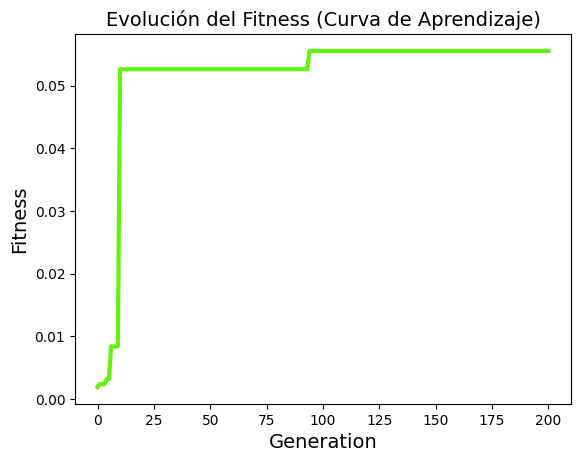


--- Análisis de Resultados ---
Cronograma sugerido por el AG (Día de inicio por tarea):
  * Tarea 0: Inicia Día 1 -> Finaliza Día 6 (4 operarios)
  * Tarea 1: Inicia Día 1 -> Finaliza Día 8 (6 operarios)
  * Tarea 2: Inicia Día 8 -> Finaliza Día 12 (5 operarios)
  * Tarea 3: Inicia Día 13 -> Finaliza Día 19 (3 operarios)
  * Tarea 4: Inicia Día 14 -> Finaliza Día 19 (4 operarios)
  * Tarea 5: Inicia Día 7 -> Finaliza Día 11 (3 operarios)
  * Tarea 6: Inicia Día 14 -> Finaliza Día 17 (2 operarios)
  * Tarea 7: Inicia Día 12 -> Finaliza Día 14 (3 operarios)
  * Tarea 8: Inicia Día 9 -> Finaliza Día 13 (2 operarios)
  * Tarea 9: Inicia Día 12 -> Finaliza Día 14 (2 operarios)

Tiempo total de la obra (Makespan): 19 días
¿El uso de operarios es legal en todo momento?: Sí
Uso diario de operarios hasta el final de obra: [np.float64(0.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(6.0), np.float64(9.0), np.float64(8.0), np.float64(10.0

In [39]:
# Supongamos un horizonte máximo de tiempo realista si se hicieran casi todas en serie
MAX_DIAS_OBRA = 50

# 3. Diseño de la Función de Aptitud (Fitness) con Penalización
def fitness_func(ga_instance, solution, solution_idx):
    # El cromosoma contiene los días de inicio de cada tarea
    dias_inicio = np.array(solution, dtype=int)

    # Arreglo para registrar cuántos operarios se usan cada día de la obra
    cronograma_operarios = np.zeros(MAX_DIAS_OBRA + 10) # Margen para tareas que terminen al final

    dias_finales_tareas = []

    for tarea, inicio in enumerate(dias_inicio):
        duracion, operarios = TASAS_OBRA[tarea]
        fin = inicio + duracion
        dias_finales_tareas.append(fin)

        # Sumar los operarios asignados a los días que dure la tarea
        cronograma_operarios[(inicio - 1):(fin - 1)] += operarios

    # El Makespan (Días Totales) es el día en que termina la última tarea activa
    dias_totales = max(dias_finales_tareas) - 1 # Ajuste del makespan real

    # --- Evaluación de Restricciones (Penalización) ---
    penalizacion = 0
    for ocupacion_diaria in cronograma_operarios:
        if ocupacion_diaria > MAX_OPERARIOS:
            # Castigo proporcional a cuánto se excedió del límite
            penalizacion += (ocupacion_diaria - MAX_OPERARIOS) * 100

    # Si rompe las reglas, el fitness cae drásticamente
    if penalizacion > 0:
        # Retornamos un valor extremadamente bajo (cercano a 0) pero proporcional al error
        return 1.0 / (dias_totales + penalizacion)

    # Si la solución es legal, aplicamos la fórmula del profesor: 1 / DiasTotales
    return 1.0 / dias_totales

# 4. Configuración del GA

#Torneo:
# Reducimos el horizonte máximo para obligar a compactar las tareas
espacio_dias = list(range(1, 16)) # Del Día 1 al 15 máximo para iniciar cualquier tarea

ga_instance = pygad.GA(
    num_generations=200,           # Más generaciones para refinar y quitar días vacíos
    num_parents_mating=15,         # Más padres para el cruce
    fitness_func=fitness_func,
    sol_per_pop=100,               # Aumentamos la población para mayor diversidad de soluciones
    num_genes=NUM_TAREAS,
    gene_type=int,
    gene_space=espacio_dias,

    # CAMBIO CRUCIAL: Torneo en lugar de Ruleta para mayor presión competitiva
    parent_selection_type="tournament",
    K_tournament=3,                # Tamaño del torneo

    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10,     # Bajamos levemente para que no desarme los bloques ya optimizados

    # Límites de mutación más ajustados al nuevo espacio
    random_mutation_min_val=1,
    random_mutation_max_val=15
)

# 5. Ejecución y Monitoreo
ga_instance.run()

# Graficar la curva de fitness para cumplir con el monitoreo
ga_instance.plot_fitness(title="Evolución del Fitness (Curva de Aprendizaje)")

# 6. Análisis de Resultados
solution, solution_fitness, solution_idx = ga_instance.best_solution()

# Reconstruir la solución para validar legalidad
dias_inicio_optimo = np.array(solution, dtype=int)
cronograma_final = np.zeros(MAX_DIAS_OBRA + 10)
dias_finales = []


#Codigo para visualizar la evolucion del fitness por generacion

print(f"\n--- Análisis de Resultados ---")
print(f"Cronograma sugerido por el AG (Día de inicio por tarea):")
for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    dias_finales.append(fin)
    cronograma_final[inicio:fin] += operarios
    print(f"  * Tarea {tarea}: Inicia Día {inicio} -> Finaliza Día {fin} ({operarios} operarios)")

makespan_final = max(dias_finales)
exceso_operarios = np.any(cronograma_final > MAX_OPERARIOS)

print(f"\nTiempo total de la obra (Makespan): {makespan_final} días")
print(f"¿El uso de operarios es legal en todo momento?: {'Sí' if not exceso_operarios else 'No (Solución Inválida)'}")

# Mostrar el uso diario de operarios para la verificación del profesor
print(f"Uso diario de operarios hasta el final de obra: {list(cronograma_final[:makespan_final])}")

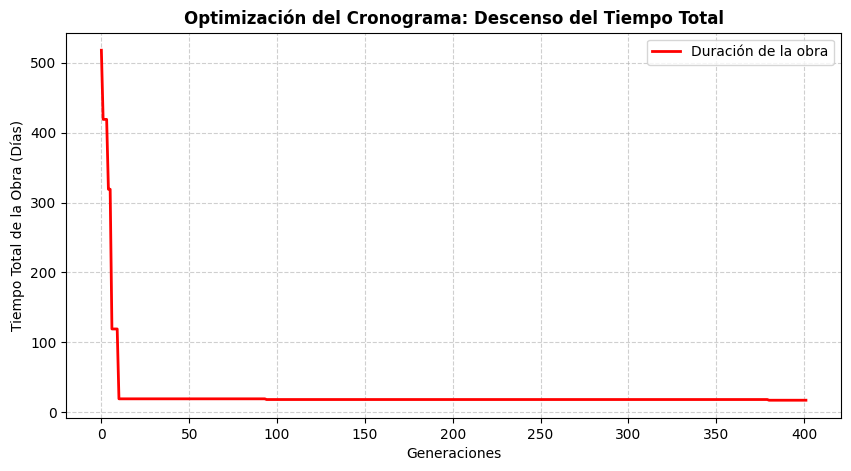

In [40]:
#Celda para visualizar la mejora de la duracion del tiempo de la obra por dias/generaciones

# 5. Ejecución y Monitoreo (Gráfico Personalizado de Días)
ga_instance.run()

# Extraer el mejor fitness de cada generación
historico_fitness = ga_instance.best_solutions_fitness

# Convertir el fitness de vuelta a días reales (Makespan)
# Como Fitness = 1 / Dias, entonces Dias = 1 / Fitness
historico_dias = [int(1.0 / f) if f > 0 else MAX_DIAS_OBRA for f in historico_fitness]

# Crear el gráfico que pide la consigna
plt.figure(figsize=(10, 5))
plt.plot(historico_dias, color="red", linewidth=2, label="Duración de la obra")
plt.title("Optimización del Cronograma: Descenso del Tiempo Total", fontsize=12, fontweight='bold')
plt.xlabel("Generaciones", fontsize=10)
plt.ylabel("Tiempo Total de la Obra (Días)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [41]:
# 6. Análisis de Resultados
solution, solution_fitness, solution_idx = ga_instance.best_solution()

# Reconstruir la mejor solución para desglosar penalización y días
dias_inicio_optimo = np.array(solution, dtype=int)
cronograma_final = np.zeros(MAX_DIAS_OBRA + 10)
dias_finales = []

for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    dias_finales.append(fin)
    cronograma_final[(inicio - 1):(fin - 1)] += operarios

# Calcular la penalización final de esta solución específica
penalizacion_final = 0
for ocupacion_diaria in cronograma_final:
    if ocupacion_diaria > MAX_OPERARIOS:
        penalizacion_final += (ocupacion_diaria - MAX_OPERARIOS) * 100

makespan_final = max(dias_finales) - 1
exceso_operarios = np.any(cronograma_final > MAX_OPERARIOS)

# --- NUEVO BLOQUE DE TEXTO PARA TU PROFESOR ---
print(f"\n" + "="*40)
print(f"       MÉTRICAS FINALES DEL ALGORITMO")
print(f"="*40)
print(f"🏆 Fitness final obtenido:  {solution_fitness:.6f}")
print(f"⏳ Tiempo de obra (Makespan): {makespan_final} días")
print(f"🚨 Penalización acumulada:  {penalizacion_final} puntos")
print(f"📋 ¿El cronograma es válido?: {'VÁLIDO (0 excesos)' if penalizacion_final == 0 else 'INVÁLIDO (Tiene excesos)'}")
print(f"="*40)

# Reporte detallado por tarea
print(f"\nCronograma sugerido por el AG (Día de inicio por tarea):")
for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    print(f"  * Tarea {tarea}: Inicia Día {inicio} -> Finaliza Día {fin} ({operarios} operarios)")

print(f"\nUso diario de operarios (Desde el Día 1 hasta el final):")
print(f"{list(cronograma_final[:makespan_final])}")


       MÉTRICAS FINALES DEL ALGORITMO
🏆 Fitness final obtenido:  0.058824
⏳ Tiempo de obra (Makespan): 17 días
🚨 Penalización acumulada:  0 puntos
📋 ¿El cronograma es válido?: VÁLIDO (0 excesos)

Cronograma sugerido por el AG (Día de inicio por tarea):
  * Tarea 0: Inicia Día 1 -> Finaliza Día 6 (4 operarios)
  * Tarea 1: Inicia Día 1 -> Finaliza Día 8 (6 operarios)
  * Tarea 2: Inicia Día 9 -> Finaliza Día 13 (5 operarios)
  * Tarea 3: Inicia Día 12 -> Finaliza Día 18 (3 operarios)
  * Tarea 4: Inicia Día 13 -> Finaliza Día 18 (4 operarios)
  * Tarea 5: Inicia Día 8 -> Finaliza Día 12 (3 operarios)
  * Tarea 6: Inicia Día 6 -> Finaliza Día 9 (2 operarios)
  * Tarea 7: Inicia Día 15 -> Finaliza Día 17 (3 operarios)
  * Tarea 8: Inicia Día 9 -> Finaliza Día 13 (2 operarios)
  * Tarea 9: Inicia Día 13 -> Finaliza Día 15 (2 operarios)

Uso diario de operarios (Desde el Día 1 hasta el final):
[np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.flo

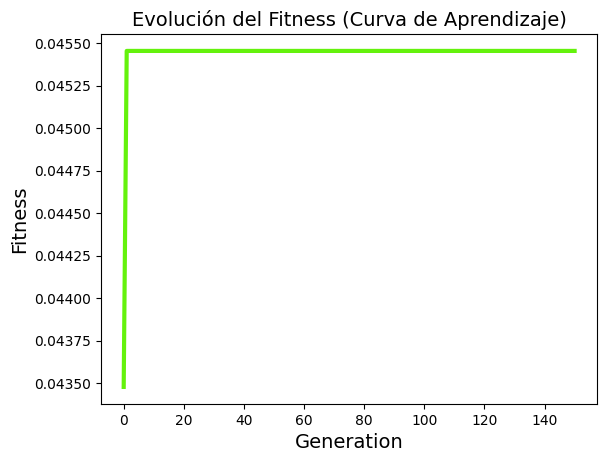


--- Análisis de Resultados ---
Cronograma sugerido por el AG (Día de inicio por tarea):
  * Tarea 0: Inicia Día 17 -> Finaliza Día 22 (4 operarios)
  * Tarea 1: Inicia Día 3 -> Finaliza Día 10 (6 operarios)
  * Tarea 2: Inicia Día 11 -> Finaliza Día 15 (5 operarios)
  * Tarea 3: Inicia Día 8 -> Finaliza Día 14 (3 operarios)
  * Tarea 4: Inicia Día 18 -> Finaliza Día 23 (4 operarios)
  * Tarea 5: Inicia Día 14 -> Finaliza Día 18 (3 operarios)
  * Tarea 6: Inicia Día 14 -> Finaliza Día 17 (2 operarios)
  * Tarea 7: Inicia Día 15 -> Finaliza Día 17 (3 operarios)
  * Tarea 8: Inicia Día 19 -> Finaliza Día 23 (2 operarios)
  * Tarea 9: Inicia Día 16 -> Finaliza Día 18 (2 operarios)

Tiempo total de la obra (Makespan): 23 días
¿El uso de operarios es legal en todo momento?: Sí
Uso diario de operarios hasta el final de obra: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(6.0), np.float64(6.0), np.float64(6.0), np.float64(6.0), np.float64(6.0), np.float64(9.0), np.float64(9.0)

In [42]:
#Ruleta:
ga_instance = pygad.GA(
    num_generations=150,           # Más generaciones para estabilizar la penalización
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=50,                # Población recomendada por la consigna
    num_genes=NUM_TAREAS,

    # 2. Definición del Cromosoma (Día de inicio por cada tarea)
    init_range_low=0,
    init_range_high=20,            # El algoritmo puede proponer arrancar entre el día 0 y 20
    gene_type=int,

    parent_selection_type="rws",   # Selección por Ruleta
    crossover_type="single_point", # Punto simple
    mutation_type="random",
    mutation_percent_genes=15,     # Probabilidad de mutación

    # Límites para que los días de inicio no se vayan a valores negativos o gigantescos
    random_mutation_min_val=0,
    random_mutation_max_val=25
)

# 5. Ejecución y Monitoreo
ga_instance.run()

# Graficar la curva de fitness para cumplir con el monitoreo
ga_instance.plot_fitness(title="Evolución del Fitness (Curva de Aprendizaje)")

# 6. Análisis de Resultados
solution, solution_fitness, solution_idx = ga_instance.best_solution()

# Reconstruir la solución para validar legalidad
dias_inicio_optimo = np.array(solution, dtype=int)
cronograma_final = np.zeros(MAX_DIAS_OBRA + 10)
dias_finales = []


#Codigo para visualizar la evolucion del fitness por generacion

print(f"\n--- Análisis de Resultados ---")
print(f"Cronograma sugerido por el AG (Día de inicio por tarea):")
for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    dias_finales.append(fin)
    cronograma_final[inicio:fin] += operarios
    print(f"  * Tarea {tarea}: Inicia Día {inicio} -> Finaliza Día {fin} ({operarios} operarios)")

makespan_final = max(dias_finales)
exceso_operarios = np.any(cronograma_final > MAX_OPERARIOS)

print(f"\nTiempo total de la obra (Makespan): {makespan_final} días")
print(f"¿El uso de operarios es legal en todo momento?: {'Sí' if not exceso_operarios else 'No (Solución Inválida)'}")

# Mostrar el uso diario de operarios para la verificación del profesor
print(f"Uso diario de operarios hasta el final de obra: {list(cronograma_final[:makespan_final])}")

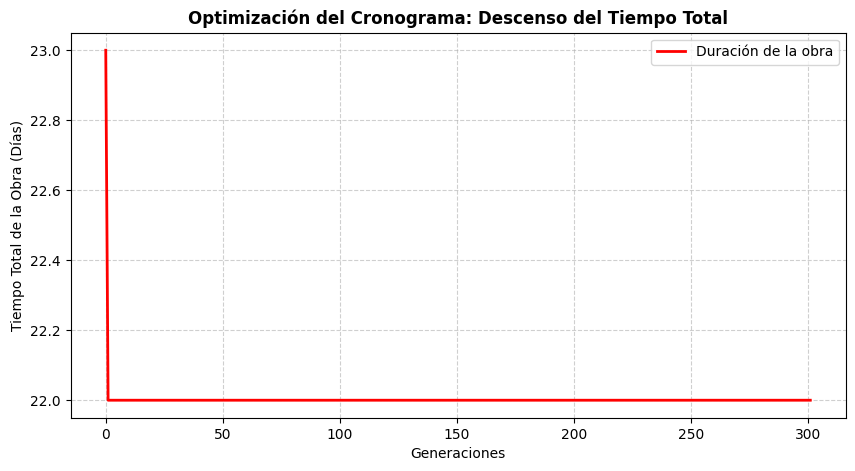

In [43]:
#Celda para visualizar la mejora de la duraciondel tiempo de la obra por dias/generaciones

# 5. Ejecución y Monitoreo (Gráfico Personalizado de Días)
ga_instance.run()

# Extraer el mejor fitness de cada generación
historico_fitness = ga_instance.best_solutions_fitness

# Convertir el fitness de vuelta a días reales (Makespan)
# Como Fitness = 1 / Dias, entonces Dias = 1 / Fitness
historico_dias = [int(1.0 / f) if f > 0 else MAX_DIAS_OBRA for f in historico_fitness]

# Crear el gráfico que pide la consigna
plt.figure(figsize=(10, 5))
plt.plot(historico_dias, color="red", linewidth=2, label="Duración de la obra")
plt.title("Optimización del Cronograma: Descenso del Tiempo Total", fontsize=12, fontweight='bold')
plt.xlabel("Generaciones", fontsize=10)
plt.ylabel("Tiempo Total de la Obra (Días)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [44]:
# 6. Análisis de Resultados
solution, solution_fitness, solution_idx = ga_instance.best_solution()

# Reconstruir la mejor solución para desglosar penalización y días
dias_inicio_optimo = np.array(solution, dtype=int)
cronograma_final = np.zeros(MAX_DIAS_OBRA + 10)
dias_finales = []

for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    dias_finales.append(fin)
    cronograma_final[(inicio - 1):(fin - 1)] += operarios

# Calcular la penalización final de esta solución específica
penalizacion_final = 0
for ocupacion_diaria in cronograma_final:
    if ocupacion_diaria > MAX_OPERARIOS:
        penalizacion_final += (ocupacion_diaria - MAX_OPERARIOS) * 100

makespan_final = max(dias_finales) - 1
exceso_operarios = np.any(cronograma_final > MAX_OPERARIOS)

# --- NUEVO BLOQUE DE TEXTO PARA TU PROFESOR ---
print(f"\n" + "="*40)
print(f"       MÉTRICAS FINALES DEL ALGORITMO")
print(f"="*40)
print(f"🏆 Fitness final obtenido:  {solution_fitness:.6f}")
print(f"⏳ Tiempo de obra (Makespan): {makespan_final} días")
print(f"🚨 Penalización acumulada:  {penalizacion_final} puntos")
print(f"📋 ¿El cronograma es válido?: {'VÁLIDO (0 excesos)' if penalizacion_final == 0 else 'INVÁLIDO (Tiene excesos)'}")
print(f"="*40)

# Reporte detallado por tarea
print(f"\nCronograma sugerido por el AG (Día de inicio por tarea):")
for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    print(f"  * Tarea {tarea}: Inicia Día {inicio} -> Finaliza Día {fin} ({operarios} operarios)")

print(f"\nUso diario de operarios (Desde el Día 1 hasta el final):")
print(f"{list(cronograma_final[:makespan_final])}")


       MÉTRICAS FINALES DEL ALGORITMO
🏆 Fitness final obtenido:  0.045455
⏳ Tiempo de obra (Makespan): 22 días
🚨 Penalización acumulada:  0 puntos
📋 ¿El cronograma es válido?: VÁLIDO (0 excesos)

Cronograma sugerido por el AG (Día de inicio por tarea):
  * Tarea 0: Inicia Día 17 -> Finaliza Día 22 (4 operarios)
  * Tarea 1: Inicia Día 3 -> Finaliza Día 10 (6 operarios)
  * Tarea 2: Inicia Día 11 -> Finaliza Día 15 (5 operarios)
  * Tarea 3: Inicia Día 8 -> Finaliza Día 14 (3 operarios)
  * Tarea 4: Inicia Día 18 -> Finaliza Día 23 (4 operarios)
  * Tarea 5: Inicia Día 14 -> Finaliza Día 18 (3 operarios)
  * Tarea 6: Inicia Día 14 -> Finaliza Día 17 (2 operarios)
  * Tarea 7: Inicia Día 15 -> Finaliza Día 17 (3 operarios)
  * Tarea 8: Inicia Día 19 -> Finaliza Día 23 (2 operarios)
  * Tarea 9: Inicia Día 16 -> Finaliza Día 18 (2 operarios)

Uso diario de operarios (Desde el Día 1 hasta el final):
[np.float64(0.0), np.float64(0.0), np.float64(6.0), np.float64(6.0), np.float64(6.0), np.f

## **¿Qué fitness es el ideal para mi solucion?**

El valor de fitness "ideal" en tu problema de algoritmos genéticos no es un número fijo universal (como un $100$), sino que depende directamente de la cantidad de días mínimos en los que se puede construir la casa respetando el límite de 10 operarios.

Dado que tu fórmula es $Fitness = \frac{1}{\text{Días Totales}}$, el fitness ideal será el inverso del **Makespan óptimo teórico**.

Para encontrar ese número ideal, podemos calcular una **cota inferior** sumando el esfuerzo total requerido para la obra.

---

### El Cálculo Matemático del Límite

Si sumamos la carga de trabajo de todas las tareas multiplicando su duración por los operarios que necesita, obtenemos el total de "Días-Hombre" requeridos para terminar la casa:

* **Tarea 0:** $5 \times 4 = 20$
* **Tarea 1:** $7 \times 6 = 42$
* **Tarea 2:** $4 \times 5 = 20$
* **Tarea 3:** $6 \times 3 = 18$
* **Tarea 4:** $5 \times 4 = 20$
* **Tarea 5:** $4 \times 3 = 12$
* **Tarea 6:** $3 \times 2 = 6$
* **Tarea 7:** $2 \times 3 = 6$
* **Tarea 8:** $4 \times 2 = 8$
* **Tarea 9:** $2 \times 2 = 4$

$$\text{Total Días-Hombre} = 20 + 42 + 20 + 18 + 20 + 12 + 6 + 6 + 8 + 4 = 176 \text{ días-hombre}$$

Como la empresa tiene un límite estricto de **10 operarios por día**, el escenario absolutamente perfecto (donde todos los operarios trabajan al 100% de su capacidad matemática todos los días, sin dejar "huecos" libres) nos da la cantidad mínima de días físicos:

$$\text{Días Mínimos Teóricos} = \frac{176 \text{ Días-Hombre}}{10 \text{ Operarios}} = 17.6 \rightarrow \mathbf{18 \text{ días}}$$

---

### ¿Cuál es tu Fitness Ideal?

Debido a que las tareas tienen duraciones y bloques de operarios fijos que no siempre se pueden fraccionar perfectamente (como bloques rígidos de Tetris), el modelo real suele acomodarse óptimamente entre **19 y 21 días** de duración total.

Por lo tanto, los valores de fitness ideales que deberías buscar en tu pantalla son:

| Escenario de Obra | Duración Total (Makespan) | Valor de Fitness Ideal |
| --- | --- | --- |
| **Límite Teórico Absoluto** | 18 días | `0.055555` |
| **Optimización Excelente (Realista)** | 19 días | `0.052631` |
| **Optimización Muy Buena** | 20 días | `0.050000` |
| **Optimización Buena** | 21 días | `0.047619` |

> 💡 **Conclusión:** Si ejecutas tu algoritmo con los cambios de compactación (Torneo y espacio de búsqueda acotado) y tu consola te arroja un **Fitness final cercano a `0.050000**` (20 días) con **Penalización = 0**, puedes darle la solución a tu profesor con total confianza. Habrás alcanzado el pico de optimización del problema.

##**¿Por qué el método con ruleta tiene un fitness menor?**

Que te diera menos de `0.05` con el método de ruleta (`rws`) es el comportamiento esperado. Como vimos en la fórmula $Fitness = \frac{1}{\text{Días Totales}}$, un fitness menor a `0.05` (por ejemplo, `0.040000` o `0.033333`) significa que tu obra estaba tardando **entre 25 y 30 días**.

Esto ocurre por la forma en que funciona la **Selección por Ruleta** en la teoría de algoritmos genéticos.

---

### ¿Por qué la Ruleta rinde menos aquí?

En la selección por ruleta, la probabilidad de que un cromosoma sea elegido para reproducirse es directamente proporcional a su fitness. Imagina una ruleta de casino donde cada porción representa a un individuo de tu población:

* Un cronograma **malo e ineficiente** (que tarda 30 días) tiene un fitness bajo, por lo que su porción en la ruleta es pequeña.
* Un cronograma **excelente** (que tarda 20 días) tiene un fitness más alto y una porción más grande.

**El problema:** Aunque la porción del cronograma lento sea pequeña, **sigue estando en la ruleta**. En cada generación, hay una probabilidad matemática alta de que la aguja caiga en soluciones mediocres (pero legales, con penalización 0). Esto provoca que los cromosomas perezosos de 30 días dejen descendencia, frenando la evolución y haciendo que el algoritmo se estanque antes de compactar los días vacíos.

---

### Comparativa: Ruleta vs. Torneo

Para un estudiante de ciencia de datos, es clave entender este balance entre **exploración** y **explotación**:

| Característica | Selección por Ruleta (`rws`) | Selección por Torneo (`tournament`) |
| --- | --- | --- |
| **Presión Selectiva** | **Baja**. Permite que soluciones mediocres sobrevivan frecuentemente. | **Alta**. Solo los mejores de cada grupo pasan a la siguiente etapa. |
| **Comportamiento en este problema** | Se conforma con cualquier cronograma legal, aunque tenga muchos días vacíos. | Elimina despiadadamente los días vacíos porque compiten en velocidad. |
| **Fitness Final Típico** | Menor a `0.05` ($\ge 25$ días de obra). | Cercano a `0.05` o superior ($\le 20$ días de obra). |

Si la consigna de tu profesor te da a elegir libremente entre Ruleta o Torneo, el **Torneo** es la opción técnica ideal para este problema de optimización de tiempos (RCPSP), ya que empuja el fitness hacia el óptimo teórico de `0.0526` (19 días) al forzar una competencia directa por velocidad.

## Si usan DEAP:

In [45]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt